# QUBO v2 — fetal hematopoiesis (Ranzoni et al. 2021)

Same Eq. (4) solver as v1 (`qubo_model.py`), on **Smart-seq2** fetal liver / bone marrow
from the Cvejic GitLab clone — not GEO GSE308682.

$$
\min_{F} \left[ -\alpha \sum_{i} I_{i} F_{i} + (1-\alpha)\sum_{i,j} R_{ij} F_{i} F_{j} \right], \quad Q = (1-\alpha)R - \alpha\,\mathrm{diag}(I)
$$

| | v1 | v2 |
| --- | --- | --- |
| Data | GSE308682 10x UMI | Ranzoni fetal Smart-seq2 |
| X | Pearson residuals | log1p(CPM) (default) |
| T | DPT, iroot = min HBE1 | published PAGA dpt (HSC/MPP root) |
| Cells | ~10,691 QC | ~4,463 hematopoietic |

Set **`QUBO_V2_DATA_DIR`** to the GitLab repo root (or `Data/ScanpyObjets`).
Leave **`SMOKE = True`** for a 200-cell / 80-gene check. Set **`SMOKE = False`** for the k=50 / 5,000-HVG benchmark.

Details: [`v2/README.md`](README.md).

In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

V2_DIR = Path.cwd() if (Path.cwd() / "foetal_loader.py").exists() else Path.cwd() / "v2"
REPO = V2_DIR.parent if V2_DIR.name == "v2" else Path.cwd()
os.environ.setdefault("QUBO_REPO_DIR", str(REPO))
os.environ["QUBO_V2_DATA_DIR"] = "/Users/jinshang/Projects/integrative-scrna-scatac-human-foetal"

for p in (REPO, V2_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
from qubo_model import (
    HAS_DWAVE,
    HAS_KAIWU,
    HAS_TABU,
    available_solvers,
    compute_mutual_information_matrix,
    solve_qubo_target_k,
    solver_banner,
)
from experiment import (
    compare_kaiwu_tabu_on_same_q,
    compare_with_lasso_rfr,
    load_experiment,
    print_regression_mse,
    target_cardinality,
)

print(f"Repo {REPO}")
print(f"v2   {V2_DIR}")
print(f"QUBO_V2_DATA_DIR={os.environ.get('QUBO_V2_DATA_DIR')}")
print(f"Ocean tabu={HAS_TABU}, Ocean SA={HAS_DWAVE}, Kaiwu SDK={HAS_KAIWU}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo /Users/jinshang/Projects/qubo
v2   /Users/jinshang/Projects/qubo/v2
QUBO_V2_DATA_DIR=/Users/jinshang/Projects/integrative-scrna-scatac-human-foetal
Ocean tabu=True, Ocean SA=True, Kaiwu SDK=True


## Flags

`SMOKE=True` subsamples the **real** h5ad (fast). `SMOKE=False` is the full benchmark
(pairwise MI at p=5000, same cost class as v1).

In [4]:
import qubo_model as _qubo_model

SMOKE = True                 # False → full ~4.5k cells × 5,000 HVGs, k=50
USE_REAL_DATA = True
N_TOP_GENES = 80 if SMOKE else 5000
N_CELLS = 200 if SMOKE else None
TRANSFORM = "log"            # log | pearson
TARGET_MODE = "paga_dpt"     # paga_dpt | dpt | gene
ROOT_GENE = "MLLT3"
SOLVER = "tabu"
COMPARE_KAIWU_TABU = not SMOKE
K_TARGET = 10 if SMOKE else 50

print(solver_banner(SOLVER))
print("qubo_model loaded from", _qubo_model.__file__)
print(f"SMOKE={SMOKE}  n_top_genes={N_TOP_GENES}  n_cells={N_CELLS}  transform={TRANSFORM}")
print("Available solvers:")
for name, meta in available_solvers().items():
    mark = "yes" if meta["installed"] else "no"
    print(f"  {name:12} installed={mark:3}  {meta['kind']:16}  {meta['stack']}")

X, y, true_features, feature_names, meta = load_experiment(
    use_real_data=USE_REAL_DATA,
    n_top_genes=N_TOP_GENES,
    transform=TRANSFORM,
    target_mode=TARGET_MODE,
    root_gene=ROOT_GENE,
    n_cells=N_CELLS,
)

D-Wave Ocean TabuSampler (classical, local; MATLAB tabu analog)
qubo_model loaded from /Users/jinshang/Projects/qubo/qubo_model.py
SMOKE=True  n_top_genes=80  n_cells=200  transform=log
Available solvers:
  tabu         installed=yes  classical         dwave-ocean-sdk
  sa           installed=yes  classical         dwave-ocean-sdk
  leap         installed=yes  quantum-hybrid    dwave-ocean-sdk
  custom_sa    installed=yes  classical         this repo
  kaiwu_sa     installed=yes  classical         kaiwu SDK
  kaiwu_tabu   installed=yes  classical         kaiwu SDK
  kaiwu_cim    installed=yes  quantum           kaiwu CIM (QBoson photonic); kaiwu-pytorch-plugin optional
Loading counts: /Users/jinshang/Projects/integrative-scrna-scatac-human-foetal/Data/ScanpyObjets/MergedAllSamples.h5ad
Loading PAGA / dpt: /Users/jinshang/Projects/integrative-scrna-scatac-human-foetal/Data/ScanpyObjets/MergedAllSamples_PAGA.h5ad
Smoke subsample: 200 cells (seed=0)
After min_cells=10: 200 cells × 13063 g

HVG log-CPM variance: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 1281.69it/s]

Computing log1p(CPM)...
Target T: published PAGA dpt_pseudotime (HSC/MPP root)
X=(200, 80) (log1p(CPM)), clusters=HSC-MPPs=56, MEMPs-Cycle=17, Erythroid cells=13, Monocytes 1=13, Mast cells=11, Pro-B cells=10, HSC-MPPs-Cycle=10, MEMPs=9, ...
Fetal Smart-seq2 (log1p(CPM)): X=(200, 80), y=(200,)
Feature names (first 10): ['HBG2', 'FOS', 'S100A9', 'S100A8', 'CD74', 'MPO', 'HLA-DRA (ENSG00000204287)', 'DUSP1', 'LDHA', 'HSP90AB1']


In [5]:
I, R = compute_mutual_information_matrix(X, y, n_bins=10)
print(f"Importance I (first 5): {I[:5]}")
print(f"Redundancy R (5x5):\n{R[:5, :5]}")

Redundancy R (pairwise MI): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 318.67it/s]

Importance I (first 5): [0.25812154 0.56275794 0.15610411 0.16960436 0.57166522]
Redundancy R (5x5):
[[0.         0.13279044 0.02434259 0.02434259 0.16796432]
 [0.13279044 0.         0.02662835 0.02662835 0.39298853]
 [0.02434259 0.02662835 0.         0.342831   0.06639838]
 [0.02434259 0.02662835 0.342831   0.         0.0593473 ]
 [0.16796432 0.39298853 0.06639838 0.0593473  0.        ]]


In [6]:
K = target_cardinality(X.shape[1], k=K_TARGET)
print(f"Target cardinality K={K}")

Target cardinality K=10


In [7]:
selected_features_qubo, energy, alpha, Q, report = solve_qubo_target_k(
    I, R, k=K, solver=SOLVER
)
selected_idx_qubo = np.where(selected_features_qubo == 1)[0]
print(f"α*={alpha:.4f}, energy={energy:.4f}, |F*|={len(selected_idx_qubo)}")
print(f"QUBO selected indices: {selected_idx_qubo}")
if feature_names is not None:
    print("QUBO selected genes:", [feature_names[i] for i in selected_idx_qubo])

kaiwu_idx = None
if COMPARE_KAIWU_TABU:
    kaiwu_idx = compare_kaiwu_tabu_on_same_q(
        Q,
        selected_features_qubo,
        energy,
        k=K,
        feature_names=feature_names,
    )

Bisect α for |F*|≈k:   0%|                                                                                                                                                              | 0/16 [00:00<?, ?it/s]

TabuSampler: n=80, num_reads=2, timeout=500 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:   6%|███████▍                                                                                                              | 1/16 [00:01<00:16,  1.09s/it, E=-1.30, alpha=0.5000, n_sel=9]

  α-bisect 1/16: α=0.500000  |F*|=9  energy=-1.2977  |n-k|=1
TabuSampler: n=80, num_reads=2, timeout=500 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:  12%|██████████████▋                                                                                                      | 2/16 [00:02<00:14,  1.04s/it, E=-4.27, alpha=0.7500, n_sel=21]

...

Bisect α for |F*|≈k:  19%|█████████████████████▉                                                                                               | 3/16 [00:03<00:13,  1.02s/it, E=-2.29, alpha=0.6250, n_sel=13]

  α-bisect 3/16: α=0.625000  |F*|=13  energy=-2.2901  |n-k|=3
TabuSampler: n=80, num_reads=2, timeout=500 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:  19%|█████████████████████▉                                                                                               | 3/16 [00:04<00:17,  1.37s/it, E=-1.72, alpha=0.5625, n_sel=10]

  α-bisect 4/16: α=0.562500  |F*|=10  energy=-1.7163  |n-k|=0
  kept best_alpha=0.562500 (|n-k|=0, E=-1.7163)
TabuSampler: n=80, num_reads=8, timeout=500 ms/read (Ocean default is 20 ms), first initial state = all zeros


QUBO acceptance:
  |F*|=10  target k=10  tol=2
  energy reported=-1.7163  recomputed FᵀQF=-1.7163
  empty mask energy=0  best singleton Q[35,35]=-0.4232
  one-bit moves that would lower E: turn_off=0  turn_on=0
  PASS: energy beats empty/singleton and cardinality is near k.
α*=0.5625, energy=-1.7163, |F*|=10
QUBO selected indices: [ 1  3  9 15 16 19 29 35 41 78]
QUBO selected genes: ['FOS', 'S100A8', 'HSP90AB1', 'HBA2', 'CD164', 'HLA-B (ENSG00000234745)', 'HIST1H4C', 'RPS14', 'SELL', 'CD34']


LASSO path: α=0.03175, n_nonzero=10 (target K=10)
Fitting random forest (100 trees)...

=== Feature selection (K=10) ===
QUBO:                [1, 3, 9, 15, 16, 19, 29, 35, 41, 78]
LASSO:               [0, 9, 11, 14, 15, 16, 33, 41, 54, 78]
Random forest:       [0, 9, 11, 14, 16, 25, 35, 41, 60, 78]
Overlaps: Q∩L=5/10, Q∩RF=5/10, L∩RF=7/10, all3=4
QUBO genes:          ['FOS', 'S100A8', 'HSP90AB1', 'HBA2', 'CD164', 'HLA-B (ENSG00000234745)', 'HIST1H4C', 'RPS14', 'SELL', 'CD34']
LASSO genes:         ['HBG2', 'HSP90AB1', 'RPS18 (ENSG00000231500)', 'NPM1', 'HBA2', 'CD164', 'DNAJB1', 'SELL', 'IGLL1', 'CD34']
RF genes:            ['HBG2', 'HSP90AB1', 'RPS18 (ENSG00000231500)', 'NPM1', 'CD164', 'HBG1', 'RPS14', 'SELL', 'PTMA', 'CD34']


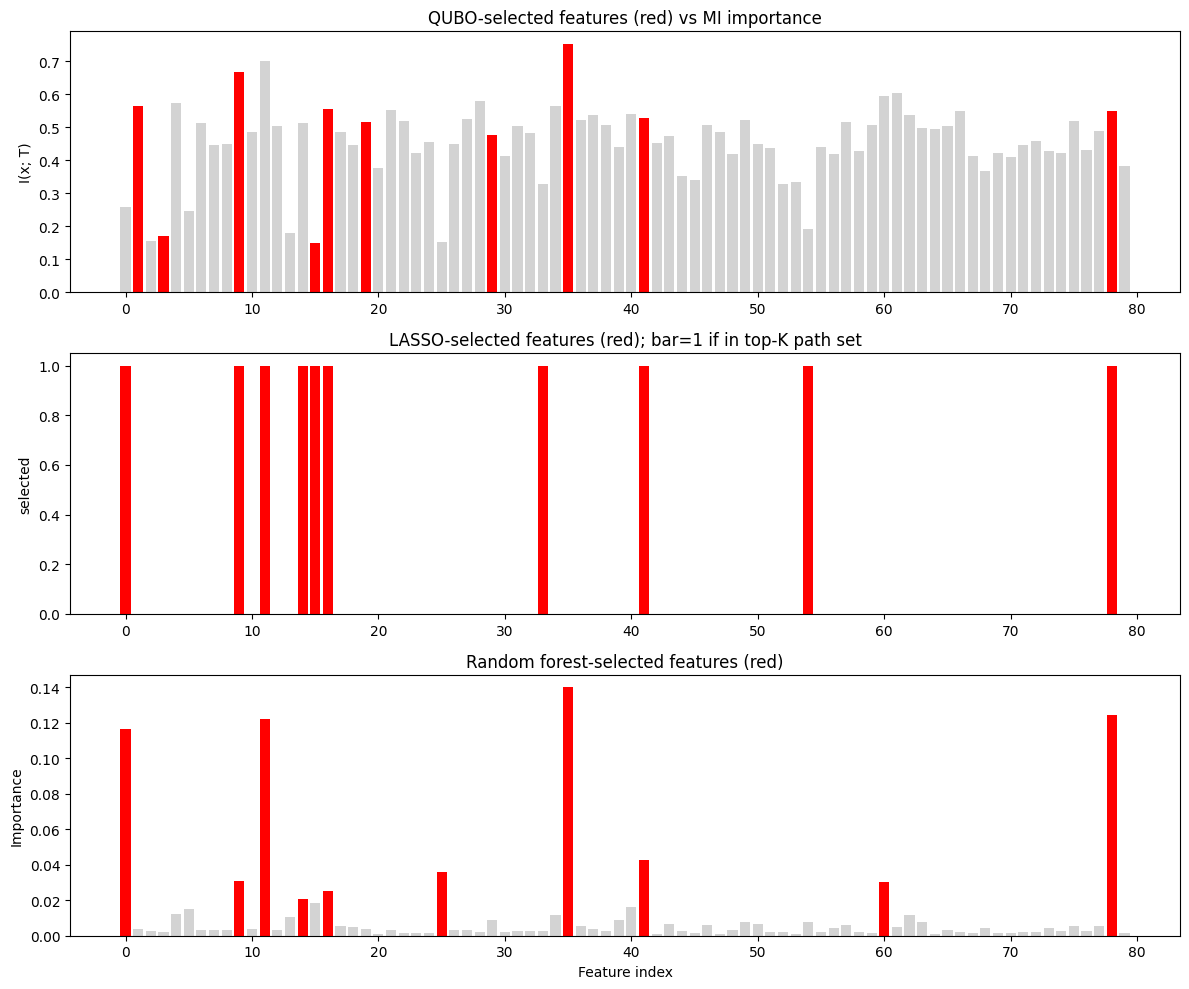

Regression MSE (z-scored Ridge α=1):
  QUBO Ocean tabu (k=10): 0.0122
  LASSO (k=10): 0.0118
  RF (k=10): 0.0126
  All features: 0.0202


In [8]:
k_compare = K
if not report["accepted"]:
    print(
        "QUBO did not pass energy/cardinality acceptance. "
        f"LASSO and RF are compared at target K={K}, not |F*|={len(selected_idx_qubo)}."
    )
selected_idx_lasso, selected_idx_rf = compare_with_lasso_rfr(
    X, y, I, true_features, selected_idx_qubo, K=k_compare, feature_names=feature_names
)
extra = {}
if kaiwu_idx is not None:
    extra["QUBO Kaiwu tabu"] = kaiwu_idx
print_regression_mse(
    X, y, selected_idx_qubo, selected_idx_lasso, selected_idx_rf, extra=extra
)